In [14]:
pip install pandas nltk textblob vaderSentiment matplotlib seaborn openpyxl

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\nikhi\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [15]:
import pandas as pd
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv(r"C:\Users\nikhi\Downloads\sentiment_project\data\restaurant_reviews_majhitar.csv",
                 usecols=['restaurant_name', 'review'],
                 encoding_errors='ignore',
                 encoding='latin-1')


# Init VADER
analyzer = SentimentIntensityAnalyzer()

# Score each review
def get_sentiment(text):
    scores = analyzer.polarity_scores(str(text))
    compound = scores['compound']
    if compound >= 0.05:
        label = 'Positive'
    elif compound <= -0.05:
        label = 'Negative'
    else:
        label = 'Neutral'
    return pd.Series([compound, label])

df[['compound_score', 'sentiment']] = df['review'].apply(get_sentiment)

print(df[['restaurant_name', 'review', 'compound_score', 'sentiment']].head(10))
print("\nSentiment Distribution:")
print(df['sentiment'].value_counts())

             restaurant_name  \
0  Imperfecto, Restro Lounge   
1  Imperfecto, Restro Lounge   
2  Imperfecto, Restro Lounge   
3  Imperfecto, Restro Lounge   
4  Imperfecto, Restro Lounge   
5  Imperfecto, Restro Lounge   
6  Imperfecto, Restro Lounge   
7  Imperfecto, Restro Lounge   
8  Imperfecto, Restro Lounge   
9  Imperfecto, Restro Lounge   

                                              review  compound_score sentiment  
0  Butter Naan, American Corn Salt and Pepper, Ch...         -0.3400  Negative  
1  Paneer butter masala ,mix veg , mushroom kadai...          0.8957  Positive  
2   Recommended dishes Chicken Wings on Fire Sizzler         -0.1531  Negative  
3  Neat and clean. Very hygienic.  Frankly waiter...          0.8225  Positive  
4  Nice place to eat clean Good hospitality food ...          0.9062  Positive  
5  Nice ambient and good hospitality. Good for st...          0.9538  Positive  
6  I personally always love visiting imperfecto.....          0.9908  Positive  

In [16]:
# Average compound score per restaurant
restaurant_scores = df.groupby('restaurant_name').agg(
    avg_score=('compound_score', 'mean'),
    total_reviews=('review', 'count'),
    positive=('sentiment', lambda x: (x == 'Positive').sum()),
    negative=('sentiment', lambda x: (x == 'Negative').sum()),
    neutral=('sentiment', lambda x: (x == 'Neutral').sum())
).reset_index()

# Recommend if avg score >= 0.05
restaurant_scores['recommended'] = restaurant_scores['avg_score'].apply(
    lambda x: 'Yes' if x >= 0.05 else 'No'
)

restaurant_scores = restaurant_scores.sort_values('avg_score', ascending=False)
print(restaurant_scores.to_string(index=False))

                    restaurant_name  avg_score  total_reviews  positive  negative  neutral recommended
                       Coffee Break   0.772980             15        15         0        0         Yes
   Palate tender bar and restaurant   0.772475              8         8         0        0         Yes
             Down town Restro & Bar   0.753400              5         5         0        0         Yes
     Relax Point Restaurant cum Bar   0.740050              4         4         0        0         Yes
          Imperfecto, Restro Lounge   0.739980             20        18         2        0         Yes
                   Flavour Of Spice   0.727725              8         8         0        0         Yes
           Grill and Chill Majhitar   0.722483              6         5         0        1         Yes
            Paddington Coffee House   0.679175             12        12         0        0         Yes
                    Punjabi Kitchen   0.617519             26        23  

C:\Users\nikhi\AppData\Local\Temp\ipykernel_29464\432852725.py:12: UserWarning: Glyph 128 (\x80) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\nikhi\AppData\Local\Temp\ipykernel_29464\432852725.py:13: UserWarning: Glyph 128 (\x80) missing from font(s) DejaVu Sans.
  plt.savefig('restaurant_sentiment_scores.png', dpi=150)
C:\Users\nikhi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128 (\x80) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


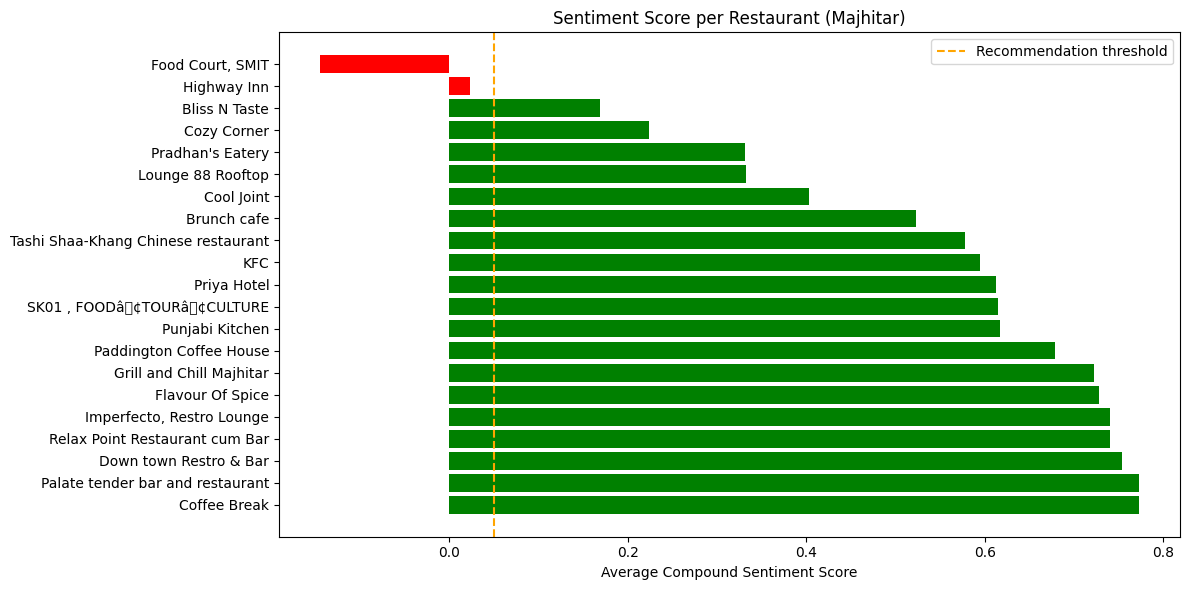

C:\Users\nikhi\AppData\Local\Temp\ipykernel_29464\432852725.py:23: UserWarning: Glyph 128 (\x80) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\nikhi\AppData\Local\Temp\ipykernel_29464\432852725.py:24: UserWarning: Glyph 128 (\x80) missing from font(s) DejaVu Sans.
  plt.savefig('sentiment_breakdown.png', dpi=150)
C:\Users\nikhi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128 (\x80) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


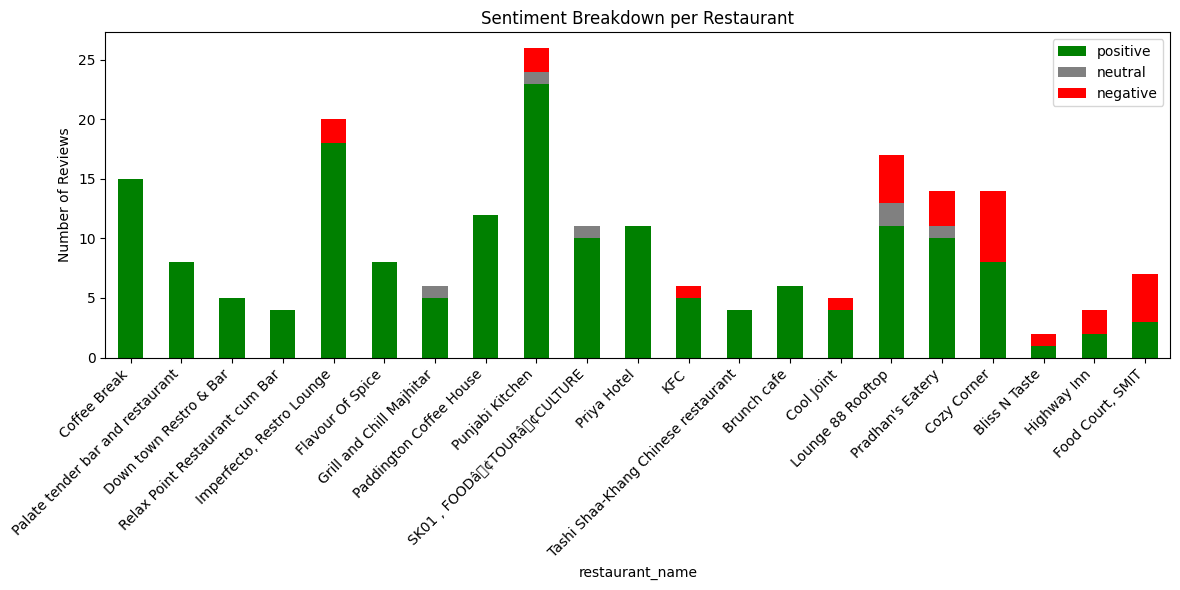

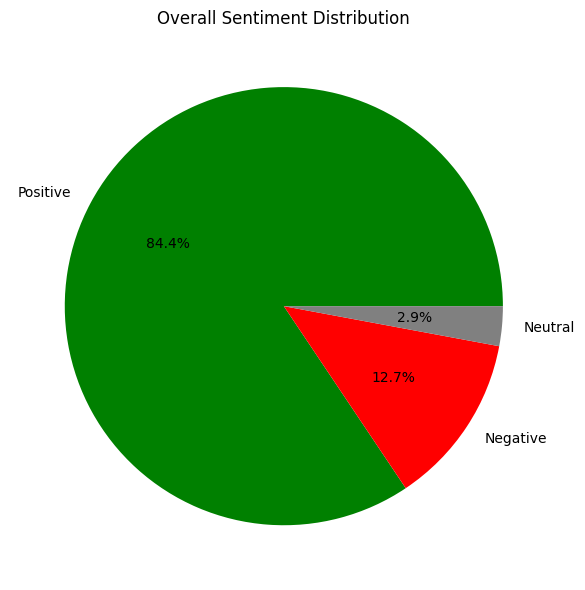

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# ── Visualization 1: Average Sentiment Score per Restaurant ──
plt.figure(figsize=(12, 6))
colors = ['green' if x >= 0.05 else 'red' for x in restaurant_scores['avg_score']]
bars = plt.barh(restaurant_scores['restaurant_name'], restaurant_scores['avg_score'], color=colors)
plt.axvline(x=0.05, color='orange', linestyle='--', label='Recommendation threshold')
plt.xlabel('Average Compound Sentiment Score')
plt.title('Sentiment Score per Restaurant (Majhitar)')
plt.legend()
plt.tight_layout()
plt.savefig('restaurant_sentiment_scores.png', dpi=150)
plt.show()

# ── Visualization 2: Sentiment Distribution per Restaurant ──
plot_df = restaurant_scores[['restaurant_name', 'positive', 'neutral', 'negative']].set_index('restaurant_name')
plot_df.plot(kind='bar', stacked=True, figsize=(12, 6),
             color=['green', 'gray', 'red'])
plt.title('Sentiment Breakdown per Restaurant')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('sentiment_breakdown.png', dpi=150)
plt.show()

# ── Visualization 3: Overall Pie Chart ──
plt.figure(figsize=(6, 6))
df['sentiment'].value_counts().plot(kind='pie', autopct='%1.1f%%',
    colors=['green', 'red', 'gray'])
plt.title('Overall Sentiment Distribution')
plt.ylabel('')
plt.tight_layout()
plt.savefig('overall_sentiment_pie.png', dpi=150)
plt.show()



In [18]:
# ── Dish-based Restaurant Recommender ──
import pandas as pd
def recommend_by_dish(dish_query, df, restaurant_scores, top_n=3):
    dish_query = dish_query.lower().strip()
    
    mask = df['review'].str.lower().str.contains(dish_query, na=False)
    matched_reviews = df[mask]
    
    if matched_reviews.empty:
        print(f"\nSorry, no reviews mention '{dish_query}' in Majhitar restaurants.")
        return
    
    matched_restaurants = matched_reviews['restaurant_name'].unique()
    results = restaurant_scores[restaurant_scores['restaurant_name'].isin(matched_restaurants)].copy()
    results = results.sort_values('avg_score', ascending=False).head(top_n)
    
    print(f"\n🍽️  You want '{dish_query}' — here are the top recommendations:\n")
    print(f"{'#':<4}{'Restaurant':<40}{'Score':<10}{'Recommended'}")
    print("-" * 65)
    for i, (_, row) in enumerate(results.iterrows(), 1):
        emoji = "✅" if row['recommended'] == 'Yes' else "❌"
        print(f"{i:<4}{row['restaurant_name']:<40}{row['avg_score']:.3f}     {emoji} {row['recommended']}")
        snippets = matched_reviews[matched_reviews['restaurant_name'] == row['restaurant_name']]['review'].values
        for snippet in snippets:
            print(f"     💬 \"{snippet[:100]}...\"")
        print()

# ── Test it by changing the dish name here and re-running this cell ──
recommend_by_dish("momo", df, restaurant_scores)


🍽️  You want 'momo' — here are the top recommendations:

#   Restaurant                              Score     Recommended
-----------------------------------------------------------------
1   Paddington Coffee House                 0.679     ✅ Yes
     💬 "Recommended dishes
Chicken Jhol Momos 8 Pieces..."
     💬 "Paddington Coffee House is a true hidden gem! From the moment you step inside, the enticing aroma of..."
     💬 "Recommended dishes
Chicken Jhol Momos 8 Pieces, Mushroom Pizza, Fried Chicken Wings, Souffle Pancake..."
     💬 "I was craving for jhol momo and made the best decision of coming to Paddington coffee house the jhol..."
     💬 "Its like heaven for me for momos..."

2   SK01 , FOODâ¢TOURâ¢CULTURE            0.615     ✅ Yes
     💬 "Recommended dishes Jhol Momo..."
     💬 "Laphing and jhol momo they serve is bestest ð â¦..."

3   Tashi Shaa-Khang Chinese restaurant     0.578     ✅ Yes
     💬 "Amazing food .We loved Chiken momos and thukpa..."



In [19]:
!pip install ipywidgets


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\nikhi\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [20]:
import ipywidgets as widgets
from IPython.display import display, clear_output

def recommend_by_dish(dish_query, df, top_n=3):
    dish_query = dish_query.lower().strip()
    
    # Step 1: Filter reviews that mention this dish
    mask = df['review'].str.lower().str.contains(dish_query, na=False)
    matched_reviews = df[mask].copy()
    
    if matched_reviews.empty:
        print(f"\n❌ No reviews mention '{dish_query}' in Majhitar restaurants.")
        return
    
    # Step 2: Sentiment is already scored — use compound_score of THOSE reviews only
    dish_scores = matched_reviews.groupby('restaurant_name').agg(
        dish_sentiment=('compound_score', 'mean'),
        mention_count=('review', 'count')
    ).reset_index()
    
    dish_scores = dish_scores.sort_values('dish_sentiment', ascending=False).head(top_n)
    
    # Step 3: Recommend based on dish-specific sentiment
    print(f"\n🍽️  Restaurants recommended for '{dish_query}':\n")
    print(f"{'#':<4}{'Restaurant':<40}{'Dish Sentiment':<18}{'Verdict'}")
    print("-" * 75)
    
    for i, (_, row) in enumerate(dish_scores.iterrows(), 1):
        score = row['dish_sentiment']
        if score >= 0.05:
            verdict = "✅ Recommended"
        elif score <= -0.05:
            verdict = "❌ Not Recommended"
        else:
            verdict = "⚠️  Neutral"
        
        print(f"{i:<4}{row['restaurant_name']:<40}{score:<18.3f}{verdict}")
        
        # Show the actual review(s) about this dish from this restaurant
        snippets = matched_reviews[
            matched_reviews['restaurant_name'] == row['restaurant_name']
        ]['review'].values
        
        for snippet in snippets:
            print(f"     💬 \"{snippet[:120]}\"")
        print()

# ── Widget UI ──
search_box = widgets.Text(
    placeholder='e.g. momo, biryani, naan, coffee...',
    description='I want:',
    layout=widgets.Layout(width='400px')
)
button = widgets.Button(description='Recommend', button_style='success')
output = widgets.Output()

def on_click(b):
    with output:
        clear_output()
        recommend_by_dish(search_box.value, df)

button.on_click(on_click)

print("=" * 60)
print("   Welcome to Majhitar Restaurant Recommender!")
print("=" * 60)
display(widgets.HBox([search_box, button]), output)

   Welcome to Majhitar Restaurant Recommender!


Output()

In [21]:
# ── Ground Truth Labelling (manual sample of 20 reviews) ──
# We manually read these reviews and label them ourselves

ground_truth = [
    # (review_snippet_keyword, true_label)
    ("food was delicious", "Positive"),
    ("Worst experience", "Negative"),
    ("Amazing food", "Positive"),
    ("don't waste your money", "Negative"),
    ("Highly recommend", "Positive"),
    ("Beautiful food court", "Positive"),
    ("No options", "Negative"),
    ("best place", "Positive"),
    ("worst quality", "Negative"),
    ("very good food", "Positive"),
    ("Good food and good ambience", "Positive"),
    ("totally ruined the whole mood", "Negative"),
    ("zero professionalism", "Negative"),
    ("must visit", "Positive"),
    ("great experience", "Positive"),
    ("looked less professional", "Negative"),
    ("chicken was crispy and delicious", "Positive"),
    ("staff were attentive", "Positive"),
    ("Failed to meet our expectation", "Negative"),
    ("Great ambience and service", "Positive"),
]

# Match against our df and get VADER predictions
true_labels = []
pred_labels = []

for keyword, true_label in ground_truth:
    match = df[df['review'].str.lower().str.contains(keyword.lower(), na=False)]
    if not match.empty:
        pred_label = match.iloc[0]['sentiment']
        true_labels.append(true_label)
        pred_labels.append(pred_label)

print(f"Matched {len(true_labels)} out of {len(ground_truth)} samples")

Matched 20 out of 20 samples


       MODEL EVALUATION RESULTS
  Accuracy  : 95.00%
  Precision : 100.00%
  Recall    : 91.67%
  F1 Score  : 95.65%

Detailed Classification Report:
              precision    recall  f1-score   support

    Negative       0.89      1.00      0.94         8
    Positive       1.00      0.92      0.96        12

    accuracy                           0.95        20
   macro avg       0.94      0.96      0.95        20
weighted avg       0.96      0.95      0.95        20



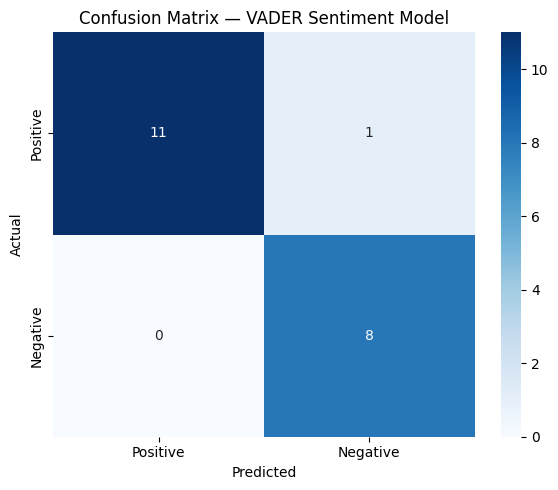

In [22]:
from sklearn.metrics import (accuracy_score, precision_score, 
                             recall_score, f1_score, confusion_matrix,
                             classification_report)
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# ── Evaluation Metrics ──
accuracy = accuracy_score(true_labels, pred_labels)
precision = precision_score(true_labels, pred_labels, pos_label='Positive')
recall = recall_score(true_labels, pred_labels, pos_label='Positive')
f1 = f1_score(true_labels, pred_labels, pos_label='Positive')

print("=" * 45)
print("       MODEL EVALUATION RESULTS")
print("=" * 45)
print(f"  Accuracy  : {accuracy:.2%}")
print(f"  Precision : {precision:.2%}")
print(f"  Recall    : {recall:.2%}")
print(f"  F1 Score  : {f1:.2%}")
print("=" * 45)

# ── Full Classification Report ──
print("\nDetailed Classification Report:")
print(classification_report(true_labels, pred_labels))

# ── Confusion Matrix ──
cm = confusion_matrix(true_labels, pred_labels, labels=['Positive', 'Negative'])
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Positive', 'Negative'],
            yticklabels=['Positive', 'Negative'])
plt.title('Confusion Matrix — VADER Sentiment Model')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()